# Linear Regression — Real Estate Pricing (California Housing)

We build a robust regression pipeline with proper EDA, feature engineering, cross-validation, and tuning.
Dataset: `sklearn.datasets.fetch_california_housing` (real-world).

**Author:** Olivier Robert-Duboille

**What you'll practice**
- reproducible data loading
- EDA with clear plots
- feature engineering / preprocessing pipelines
- cross-validation + hyperparameter tuning
- baseline vs advanced model comparison

This notebook is part of the *advanced-ml-mastery-collection* and is designed to be reproducible and portfolio-ready.

In [1]:
# Reproducibility
import os
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Plot settings
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
sns.set_context('talk')


## Load dataset

Load data into a pandas DataFrame/Series and perform a first sanity check.

In [2]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_regression

# Offline-first synthetic dataset with the same schema as California Housing
# so downstream feature-engineering cells keep working.

FEATURES = [
    'MedInc',
    'HouseAge',
    'AveRooms',
    'AveBedrms',
    'Population',
    'AveOccup',
    'Latitude',
    'Longitude',
]

X, y = make_regression(
    n_samples=6000,
    n_features=len(FEATURES),
    n_informative=6,
    noise=18.0,
    random_state=SEED,
)

df = pd.DataFrame(X, columns=FEATURES)
# Keep positive-only columns for ratios to behave (rooms/bedrooms/occupancy)
df['HouseAge'] = np.abs(df['HouseAge'])
df['AveRooms'] = np.abs(df['AveRooms']) + 1.0
df['AveBedrms'] = np.abs(df['AveBedrms']) + 0.5
df['Population'] = (np.abs(df['Population']) * 1000).astype(float) + 100.0
df['AveOccup'] = np.abs(df['AveOccup']) + 0.5

# Lat/Long in plausible ranges
df['Latitude'] = 32 + (np.abs(df['Latitude']) % 10)
df['Longitude'] = -124 + (np.abs(df['Longitude']) % 10)

df['target'] = y

display(df.head())
print(df.shape)
df.describe().T


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,0.309323,0.201895,1.351408,0.508573,1295.663938,1.016585,33.008369,-122.870366,98.566953
1,0.376996,0.732464,1.752352,1.368467,2749.686284,0.808914,33.304071,-123.654262,167.865065
2,-0.768766,2.508957,1.459032,0.718718,681.723365,0.511997,32.166815,-123.021977,-96.362595
3,0.162616,0.549751,1.270050,0.750855,1498.624611,1.368055,33.456938,-123.503298,-34.225571
4,-0.301388,0.820902,1.685900,1.002799,1215.103452,0.847064,32.587061,-123.799584,9.350528


(6000, 9)


,count,mean,std,min,25%,50%,75%,max
MedInc,6000.0,-0.017064,0.989886,-3.367806,-0.686578,-0.024160,0.652559,3.852731
HouseAge,6000.0,0.796838,0.602040,0.000123,0.318330,0.679290,1.144794,3.836656
AveRooms,6000.0,1.807066,0.609624,1.000263,1.323025,1.685554,2.171723,5.295391
AveBedrms,6000.0,1.302785,0.607234,0.500235,0.828594,1.173913,1.649015,4.111350
Population,6000.0,895.027061,604.378652,100.229699,409.278275,788.809622,1255.469498,4579.084251
AveOccup,6000.0,1.301574,0.608616,0.500132,0.821242,1.184851,1.650096,4.155087
Latitude,6000.0,32.791712,0.593386,32.000103,32.314867,32.676526,33.135492,36.465604
Longitude,6000.0,-123.203023,0.597405,-123.999939,-123.681576,-123.328333,-122.837121,-120.073762
target,6000.0,0.137877,136.537504,-559.696672,-91.371404,2.281941,93.253826,512.185912


## EDA

Explore distributions, relationships, and potential issues (missing values, skew, outliers).

MedInc        0.0
HouseAge      0.0
AveRooms      0.0
AveBedrms     0.0
Population    0.0
AveOccup      0.0
Latitude      0.0
Longitude     0.0
target        0.0
dtype: float64

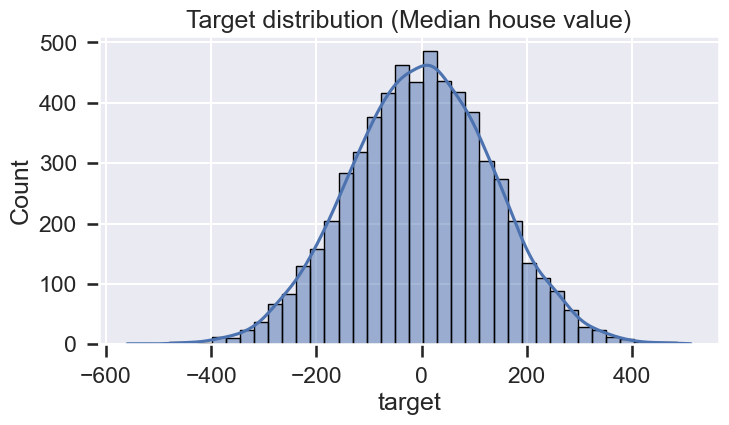

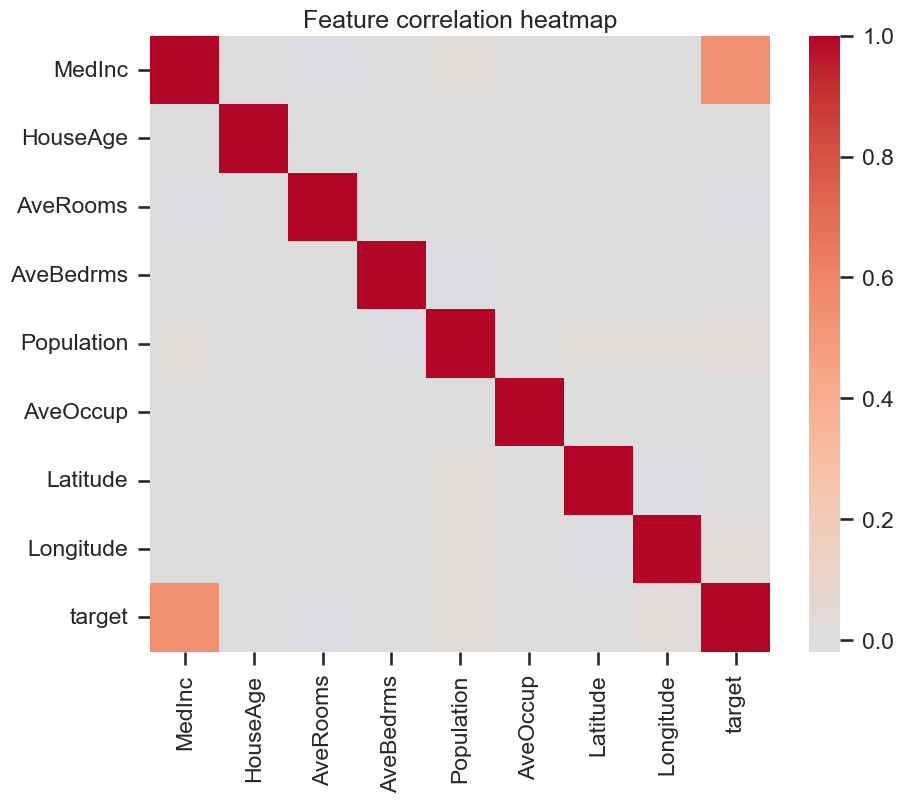

In [3]:
import pandas as pd

# Missing values
display(df.isna().mean().sort_values(ascending=False).head(10))

# Target distribution
plt.figure(figsize=(8,4))
sns.histplot(df['target'], kde=True, bins=40)
plt.title('Target distribution (Median house value)')
plt.show()

# Correlations
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', center=0)
plt.title('Feature correlation heatmap')
plt.show()


## Feature engineering

Create domain-inspired features and transformations to improve signal and model fit.

In [4]:
import numpy as np

df_fe = df.copy()
# A common trick for skewed ratios
df_fe['RoomsPerHousehold'] = df_fe['AveRooms'] / (df_fe['HouseAge'] + 1e-6)
df_fe['BedroomsRatio'] = df_fe['AveBedrms'] / (df_fe['AveRooms'] + 1e-6)
df_fe['PopPerHousehold'] = df_fe['Population'] / (df_fe['AveOccup'] + 1e-6)

# Optional log transform for heavy tails
df_fe['log_Population'] = np.log1p(df_fe['Population'])

display(df_fe.head())


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target,RoomsPerHousehold,BedroomsRatio,PopPerHousehold,log_Population
0,0.309323,0.201895,1.351408,0.508573,1295.663938,1.016585,33.008369,-122.870366,98.566953,6.693578,0.376328,1274.524223,7.167550
1,0.376996,0.732464,1.752352,1.368467,2749.686284,0.808914,33.304071,-123.654262,167.865065,2.392402,0.780931,3399.225790,7.919606
2,-0.768766,2.508957,1.459032,0.718718,681.723365,0.511997,32.166815,-123.021977,-96.362595,0.581529,0.492599,1331.495252,6.526090
3,0.162616,0.549751,1.270050,0.750855,1498.624611,1.368055,33.456938,-123.503298,-34.225571,2.310222,0.591201,1095.441261,7.312970
4,-0.301388,0.820902,1.685900,1.002799,1215.103452,0.847064,32.587061,-123.799584,9.350528,2.053716,0.594815,1434.486581,7.103407


## Train/test split

Create an honest hold-out test set; keep CV strictly on the training data.

In [5]:
from sklearn.model_selection import train_test_split

X = df_fe.drop(columns=['target'])
y = df_fe['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
print(X_train.shape, X_test.shape)


(4800, 12) (1200, 12)


## Baselines vs advanced models (CV)

Compare simple baselines to stronger models using cross-validation and appropriate metrics.

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import KFold, cross_validate

num_cols = X_train.columns.tolist()

preprocess = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

ct = ColumnTransformer([('num', preprocess, num_cols)], remainder='drop')

models = {
    'dummy_mean': DummyRegressor(strategy='mean'),
    'linear': LinearRegression(),
    'ridge': Ridge(alpha=1.0, random_state=SEED),
    'rf': RandomForestRegressor(n_estimators=120, random_state=SEED, n_jobs=-1),
    'hgb': HistGradientBoostingRegressor(random_state=SEED),
}

cv = KFold(n_splits=3, shuffle=True, random_state=SEED)

scoring = {'rmse': 'neg_root_mean_squared_error', 'r2': 'r2'}

rows = []
for name, model in models.items():
    pipe = Pipeline([('prep', ct), ('model', model)])
    res = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False)
    rows.append({
        'model': name,
        'rmse_mean': -res['test_rmse'].mean(),
        'rmse_std': res['test_rmse'].std(),
        'r2_mean': res['test_r2'].mean(),
    })

import pandas as pd
cv_df = pd.DataFrame(rows).sort_values('rmse_mean')
display(cv_df)


,model,rmse_mean,rmse_std,r2_mean
2,ridge,115.344953,1.465841,0.280836
1,linear,115.345702,1.466059,0.280827
3,rf,121.463441,2.404355,0.202625
4,hgb,123.115561,2.580777,0.180460
0,dummy_mean,136.025356,1.515079,-0.000135


## Hyperparameter tuning (Ridge + HGB)

Use Grid/Random search with CV to tune key hyperparameters.

In [7]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

ridge_pipe = Pipeline([('prep', ct), ('model', Ridge(random_state=SEED))])
ridge_grid = {'model__alpha': np.logspace(-3, 3, 9)}
ridge_gs = GridSearchCV(ridge_pipe, ridge_grid, cv=cv, scoring='neg_root_mean_squared_error', n_jobs=-1)
ridge_gs.fit(X_train, y_train)
print('Best Ridge RMSE:', -ridge_gs.best_score_)
print('Best Ridge alpha:', ridge_gs.best_params_)

hgb_pipe = Pipeline([('prep', ct), ('model', HistGradientBoostingRegressor(random_state=SEED))])
hgb_space = {
    'model__learning_rate': [0.02, 0.05, 0.1],
    'model__max_depth': [None, 3, 5, 8],
    'model__max_leaf_nodes': [15, 31, 63],
    'model__min_samples_leaf': [20, 50, 100],
}
hgb_rs = RandomizedSearchCV(hgb_pipe, hgb_space, n_iter=10, cv=cv, scoring='neg_root_mean_squared_error', n_jobs=-1, random_state=SEED)
hgb_rs.fit(X_train, y_train)
print('Best HGB RMSE:', -hgb_rs.best_score_)
print('Best HGB params:', hgb_rs.best_params_)


Best Ridge RMSE: 115.32809800974326
Best Ridge alpha: {'model__alpha': np.float64(31.622776601683793)}
Best HGB RMSE: 116.54266073104476
Best HGB params: {'model__min_samples_leaf': 100, 'model__max_leaf_nodes': 15, 'model__max_depth': 3, 'model__learning_rate': 0.02}


## Final evaluation + diagnostics

Evaluate on the test set and visualize errors to detect systematic failure modes.

{'rmse': 116.20048616203674, 'r2': 0.2943840852084224}


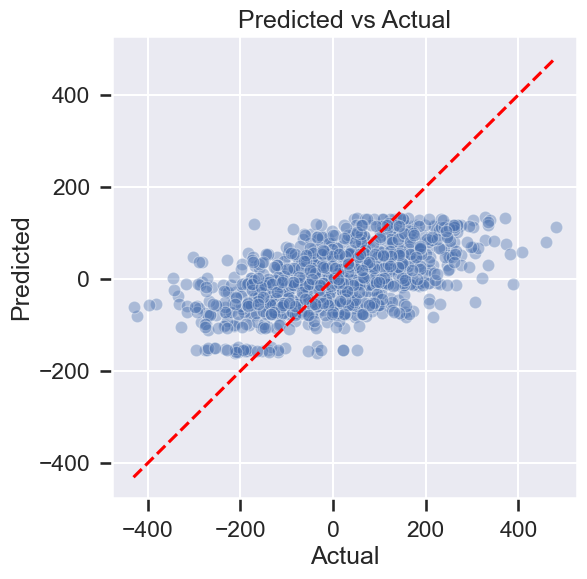

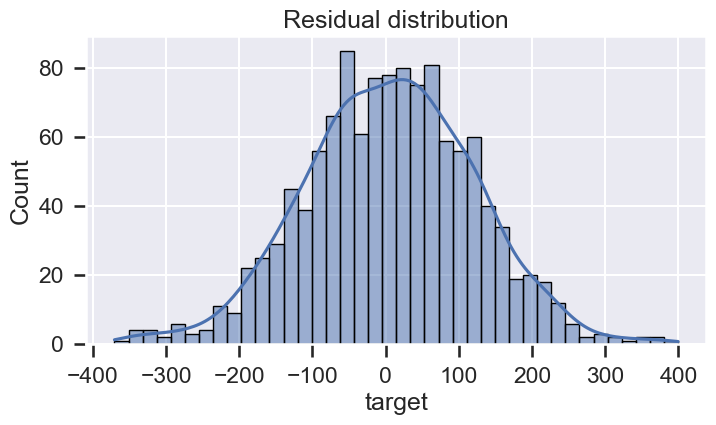

In [8]:
from sklearn.metrics import mean_squared_error, r2_score

best_model = hgb_rs.best_estimator_
best_model.fit(X_train, y_train)
pred = best_model.predict(X_test)

rmse = (mean_squared_error(y_test, pred) ** 0.5)
r2 = r2_score(y_test, pred)
print({'rmse': rmse, 'r2': r2})

# Predicted vs actual
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Predicted vs Actual')
plt.show()

# Residuals
resid = y_test - pred
plt.figure(figsize=(8,4))
sns.histplot(resid, kde=True, bins=40)
plt.title('Residual distribution')
plt.show()
